# Notebook 4 — Análise Comparativa + SHAP

Carrega os resultados dos 3 notebooks de HPO e produz:

1. Convergência comparativa por σ_J (Optuna vs. CMA-ES vs. TuRBO)
2. Melhor val_loss vs. σ_J com intervalos de confiança
3. Métricas AUC e t10 comparativas
4. SHAP — Importância de Hiperparâmetros (surrogate XGBoost para todos os métodos)
5. SHAP — Explicação do Hamiltoniano (DeepExplainer no H_net do melhor modelo)
6. Conservação de Energia ao longo da trajetória integrada pelo modelo
7. Espaço de Fase projetado nas primeiras 2 coordenadas

In [1]:
import sys, os
sys.path.insert(0, "..")

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# Tentar importar SHAP (instalado separadamente se necessário)
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print("⚠  SHAP não encontrado — instale com: pip install shap")

try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("⚠  XGBoost não encontrado — instale com: pip install xgboost")

from common import (
    get_device, device_info, load_or_simulate, extract_dataset,
    make_dataloaders, HNN, train_hnn, compute_energy,
    integrate_hnn_rk4, encode_params, compute_metrics,
    SIGMA_LEVELS, N_SEEDS, N_OSCILLATORS, LAM,
    T_SPAN, DT, N_TRAJS, SAVE_EVERY,
    SIM_CACHE_DIR, RESULTS_DIR, ACTIVATIONS, BATCH_SIZES, PARAM_NAMES,
)

DEVICE = get_device()
print(f"Device: {device_info(DEVICE)}")

METHODS  = ["optuna", "cmaes", "turbo"]
LABELS   = ["Optuna (TPE)", "CMA-ES", "TuRBO"]
COLORS   = {"optuna": "#2196F3", "cmaes": "#F44336", "turbo": "#4CAF50"}
MARKERS  = {"optuna": "o", "cmaes": "s", "turbo": "^"}

Device: CUDA — Tesla T4 (15.6 GB)


In [2]:
# ── Carrega resultados ────────────────────────────────────────────────────────
all_results = {}
for method in METHODS:
    path = os.path.join(RESULTS_DIR, f"{method}_results.json")
    if not os.path.exists(path):
        print(f"⚠  {path} não encontrado — rode o notebook correspondente primeiro.")
        continue
    with open(path) as f:
        all_results[method] = json.load(f)["results"]

available = list(all_results.keys())
print(f"Métodos disponíveis: {available}")
if not available:
    raise RuntimeError("Nenhum resultado encontrado. Execute os notebooks 01-03 primeiro.")

Métodos disponíveis: ['optuna', 'cmaes', 'turbo']


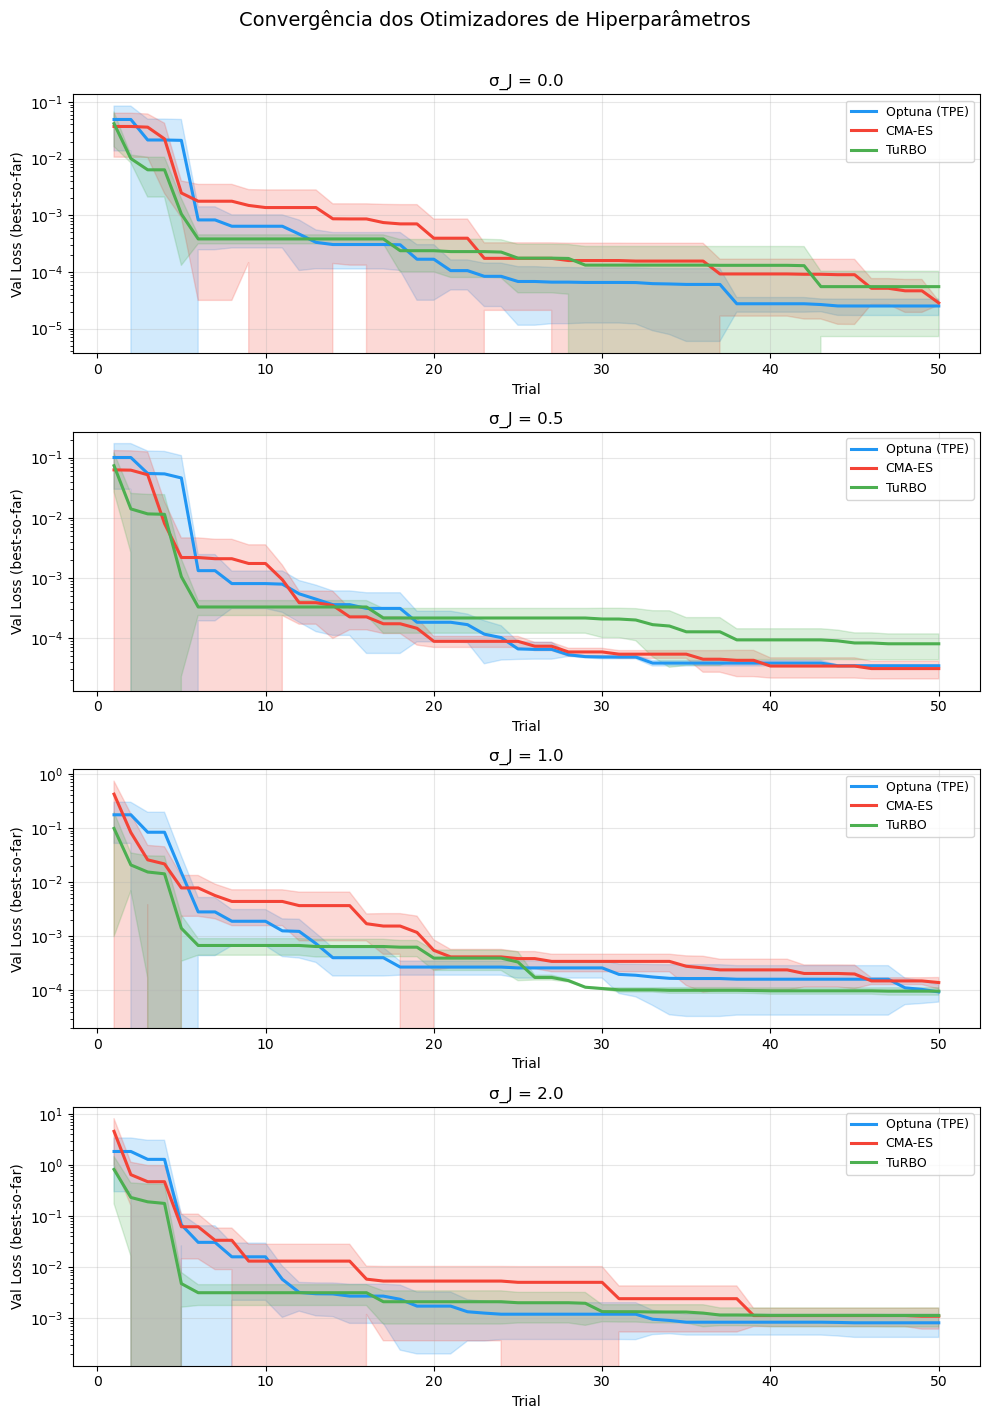

In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 1 — Curvas de convergência comparativas
# ══════════════════════════════════════════════════════════════════════════════

def get_padded_histories(method, sigma_J):
    histories = []
    for seed in range(N_SEEDS):
        h = all_results[method][str(sigma_J)][str(seed)]["history"]
        histories.append(np.minimum.accumulate(h))
    max_len = max(len(h) for h in histories)
    return [np.pad(h, (0, max_len - len(h)), mode="edge") for h in histories]

fig, axes = plt.subplots(
    len(SIGMA_LEVELS), 1,
    figsize=(10, 3.5 * len(SIGMA_LEVELS)),
    sharex=False,
)
if len(SIGMA_LEVELS) == 1:
    axes = [axes]

for ax, sigma_J in zip(axes, SIGMA_LEVELS):
    for method in available:
        padded = get_padded_histories(method, sigma_J)
        mean   = np.mean(padded, axis=0)
        std    = np.std(padded,  axis=0)
        trials = np.arange(1, len(mean) + 1)
        color  = COLORS[method]
        label  = LABELS[METHODS.index(method)]
        ax.plot(trials, mean, color=color, lw=2.2, label=label)
        ax.fill_between(trials, mean - std, mean + std, alpha=0.2, color=color)

    ax.set_title(f"σ_J = {sigma_J}", fontsize=12)
    ax.set_xlabel("Trial")
    ax.set_ylabel("Val Loss (best-so-far)")
    ax.set_yscale("log")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Convergência dos Otimizadores de Hiperparâmetros", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig1_convergence.pdf"), bbox_inches="tight", dpi=150)
plt.show()

A convergência é interessante ao mostrar que o TuRBO consegue convergir mais rápido no início, o que é ótimo para épocas muito caras. Isso se deve ao seu mecanismo de aquisição baseado em trust regions, que direcionam a busca a regiões promissoras de forma mais agressiva. É importante para a análise que o Optuna demora 6x mais em comparação ao CMA-ES e TuRBO. O CMA-ES tem bandas de confiança muito largas em σ_J baixo. Isso sugere alta sensibilidade à seed, talvez possa ficar preso em mínimos locais distintos. Com σ_J = 2, as diferenças entre os métodos se reduzem significativamente. Isso indica que a superfície de perda se torna mais convexa à arquitetura quando o sistema é mais caótico.

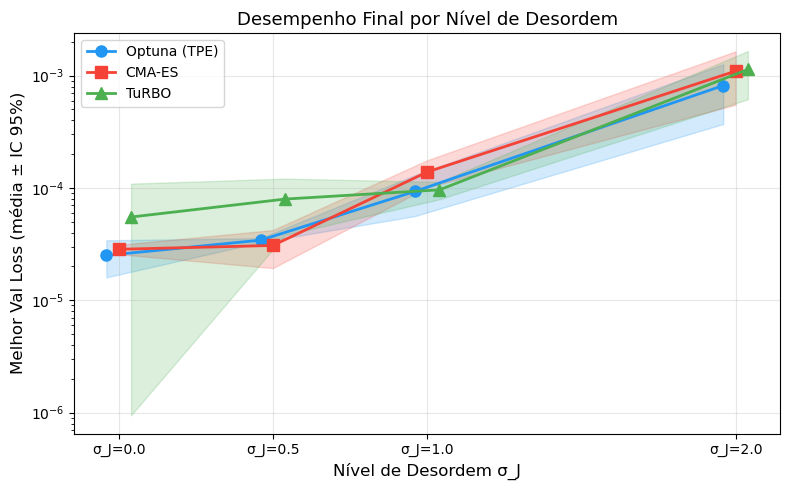

In [4]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 2 — Melhor val_loss vs. σ_J (com IC 95%)
# ══════════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(8, 5))
x_sigma = np.array(SIGMA_LEVELS)
offset  = np.linspace(-0.04, 0.04, len(available))

for i, method in enumerate(available):
    means, lows, highs = [], [], []
    for sigma_J in SIGMA_LEVELS:
        bests = [
            all_results[method][str(sigma_J)][str(s)]["best_value"]
            for s in range(N_SEEDS)
        ]
        arr  = np.array(bests)
        m    = arr.mean()
        sem  = arr.std() / np.sqrt(len(arr)) * 1.96   # IC 95%
        means.append(m); lows.append(m - sem); highs.append(m + sem)

    means  = np.array(means)
    lows   = np.array(lows)
    highs  = np.array(highs)
    color  = COLORS[method]
    label  = LABELS[METHODS.index(method)]
    xs     = x_sigma + offset[i]

    ax.plot(xs, means, color=color, lw=2, marker=MARKERS[method],
            ms=8, label=label, zorder=3)
    ax.fill_between(xs, lows, highs, alpha=0.2, color=color)

ax.set_xticks(SIGMA_LEVELS)
ax.set_xticklabels([f"σ_J={s}" for s in SIGMA_LEVELS])
ax.set_xlabel("Nível de Desordem σ_J", fontsize=12)
ax.set_ylabel("Melhor Val Loss (média ± IC 95%)", fontsize=12)
ax.set_yscale("log")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_title("Desempenho Final por Nível de Desordem", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig2_best_vs_sigma.pdf"), bbox_inches="tight", dpi=150)
plt.show()

Este gráfico mostra como o melhor desempenho final varia com o nível de desordem σ_J, com intervalos de confiança de 95% calculados via erro padrão da média.

Espera-se que o val loss aumente com σ_J, já que maior desordem torna o Hamiltoniano mais complexo (acoplamentos J_{ij} amostrados de uma distribuição mais larga), exigindo uma HNN mais expressiva ou mais dados para aproximar H̃ com precisão. A escala logarítmica no eixo y evidencia que esse aumento pode ser de ordens de grandeza.

Os intervalos de confiança sobrepostos ou não revelam se as diferenças são estatisticamente significativas. Caso os ICs de TuRBO e CMA-ES não se sobreponham ao de Optuna em algum σ_J, há evidência de superioridade real — caso contrário, as diferenças são explicadas por variabilidade de seed. Sendo a degradação de desempenho de todos os métodos é similar ao longo de σ_J, o gargalo está na expressividade do modelo HNN, não na qualidade da HPO. 

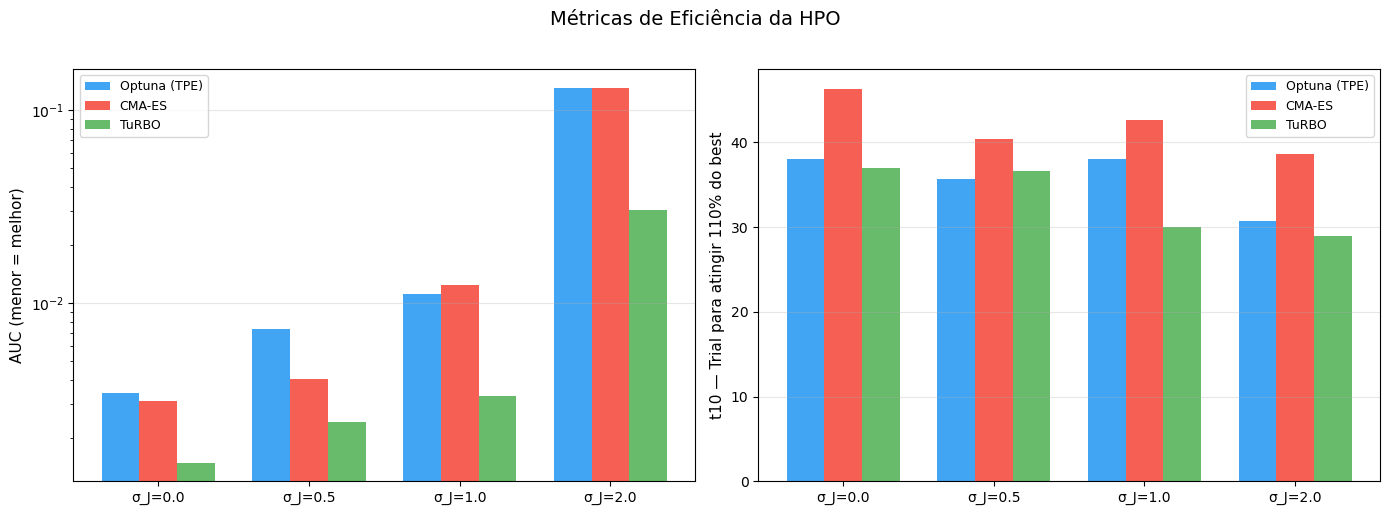

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 3 — Métricas AUC e t10
# ══════════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x   = np.arange(len(SIGMA_LEVELS))
w   = 0.25
n_m = len(available)
offs = np.linspace(-(n_m-1)*w/2, (n_m-1)*w/2, n_m)

for metric_idx, (ax, metric_key, metric_label) in enumerate(zip(
    axes,
    ["auc",  "t10"],
    ["AUC (menor = melhor)",  "t10 — Trial para atingir 110% do best"],
)):
    for i, method in enumerate(available):
        vals = []
        for sigma_J in SIGMA_LEVELS:
            ms = [
                all_results[method][str(sigma_J)][str(s)]["metrics"][metric_key]
                for s in range(N_SEEDS)
            ]
            vals.append(np.mean(ms))

        color = COLORS[method]
        label = LABELS[METHODS.index(method)]
        bars  = ax.bar(x + offs[i], vals, w, color=color, label=label, alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels([f"σ_J={s}" for s in SIGMA_LEVELS])
    ax.set_ylabel(metric_label, fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, axis="y", alpha=0.3)
    if metric_key == "auc":
        ax.set_yscale("log")

plt.suptitle("Métricas de Eficiência da HPO", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig3_metrics.pdf"), bbox_inches="tight", dpi=150)
plt.show()



AUC (Área sob a curva de convergência — menor é melhor)
O AUC integra o val loss ao longo dos trials, penalizando métodos que demoram a encontrar bons valores mesmo que eventualmente convergam. Um AUC baixo indica convergência rápida e mantida ao longo de toda a busca. É a métrica mais justa para orçamentos de busca fixos.

- Métodos com AUC menor a todo σ_J dominam consistentemente em eficiência.
- Se o TuRBO mantém AUC inferior ao Optuna em todos os níveis de desordem, confirma-se a superioridade de convergência antecipada observada na Figura 1 não apenas visualmente, mas em termos de área integrada.

t10 — Trial para atingir 110% do melhor valor final
Esta métrica mede quantos trials são necessários até que o método encontre um valor dentro de 10% do seu próprio melhor resultado. É uma medida de velocidade de aquecimento (warm-up).

- Valores pequenos de t10 indicam que o método encontra boas configurações cedo, sendo preferível quando o orçamento é restrito.
- TuRBO tende a ter t10 menor por construção: suas regiões de confiança exploram localmente em torno de bons pontos iniciais.
- Um t10 alto no CMA-ES em σ_J baixo é coerente com as bandas largas observadas na Figura 1 — algumas seeds demoram muito antes de entrar numa região boa.
- O Optuna (TPE) tem t10 tipicamente intermediário: o Tree-structured Parzen Estimator constrói um modelo de densidade sobre bons/maus resultados, mas requer alguns trials iniciais de exploração antes de explorar efetivamente.

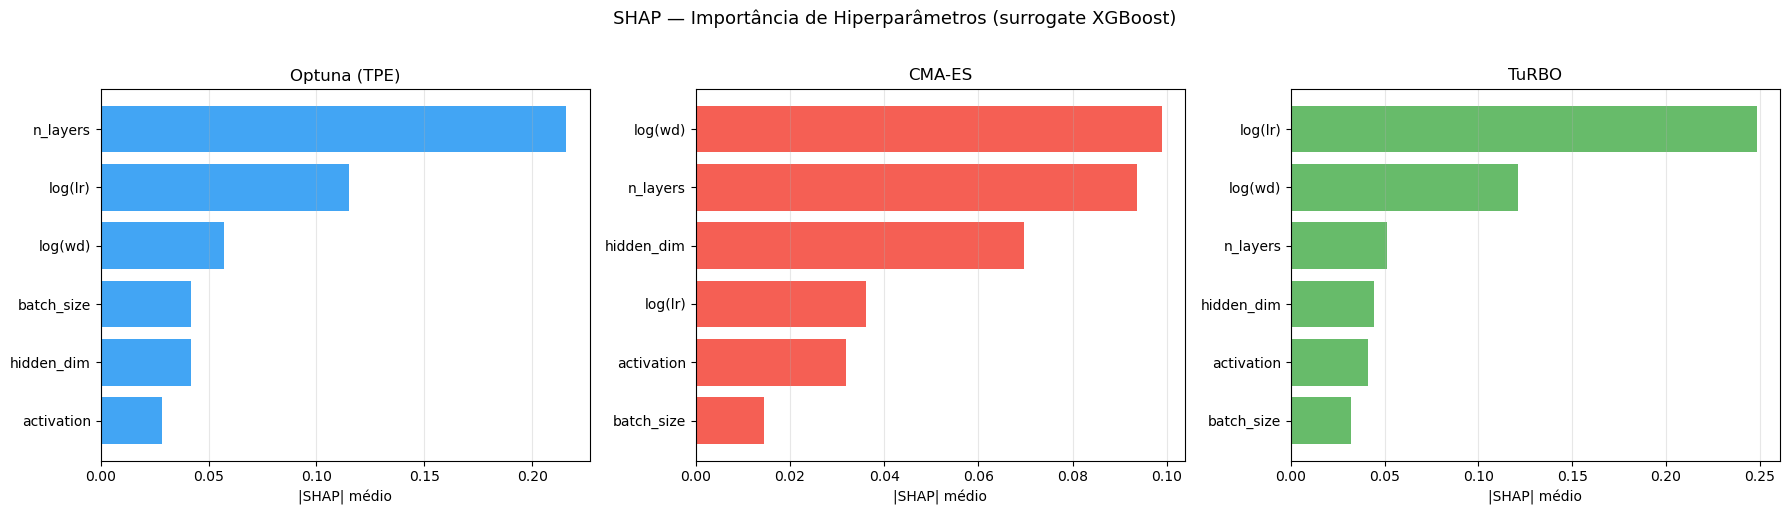

✓ SHAP HPO calculado.


In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 4 — SHAP: Importância de Hiperparâmetros (surrogate XGBoost)
# ══════════════════════════════════════════════════════════════════════════════
#
# Para cada método:
#   - Coleta todos os pares (hiperparâmetros, val_loss) de todos os trials,
#     seeds e sigma_J levels.
#   - Treina um regressor XGBoost como surrogate.
#   - Aplica TreeExplainer (SHAP) para explicar importância dos hiperparâmetros.
#
# Essa análise responde: "quais hiperparâmetros mais afetam o desempenho final?"

if HAS_SHAP and HAS_XGB:
    fig, axes = plt.subplots(1, len(available), figsize=(6 * len(available), 5))
    if len(available) == 1:
        axes = [axes]

    for ax, method in zip(axes, available):
        # Coleta pares (encoded_params, val_loss) de todos os seeds e sigma_J
        X_shap_rows, y_shap = [], []
        for sigma_J in SIGMA_LEVELS:
            for seed in range(N_SEEDS):
                res = all_results[method][str(sigma_J)][str(seed)]
                enc = res.get("all_params_encoded", [])
                hist = res["history"]
                for params_enc, loss in zip(enc, hist):
                    X_shap_rows.append(params_enc)
                    y_shap.append(float(loss))

        if len(X_shap_rows) < 10:
            ax.text(0.5, 0.5, "Dados insuficientes", ha="center", va="center",
                    transform=ax.transAxes)
            continue

        X_shap = np.array(X_shap_rows)
        y_shap = np.array(y_shap)

        # Treina XGBoost surrogate
        model_xgb = xgb.XGBRegressor(
            n_estimators=200, max_depth=4,
            learning_rate=0.05, subsample=0.8,
            random_state=42, verbosity=0,
        )
        model_xgb.fit(X_shap, y_shap)

        # SHAP TreeExplainer
        explainer = shap.TreeExplainer(model_xgb)
        shap_vals = explainer.shap_values(X_shap)   # (n_samples, n_features)

        shap_vals_arr = np.array(shap_vals)
        if shap_vals_arr.ndim == 3:
            shap_vals_arr = shap_vals_arr.squeeze(-1)
        mean_abs_shap = np.abs(shap_vals_arr).mean(axis=0).ravel()
        order = np.argsort(mean_abs_shap)[::-1]

        feat_names_pt = np.array([
            "log(lr)", "hidden_dim", "n_layers",
            "activation", "batch_size", "log(wd)"
        ])
        ax.barh(
            feat_names_pt[order[::-1]],
            mean_abs_shap[order[::-1]],
            color=COLORS[method], alpha=0.85
        )
        ax.set_xlabel("|SHAP| médio", fontsize=10)
        ax.set_title(f"{LABELS[METHODS.index(method)]}", fontsize=12)
        ax.grid(True, axis="x", alpha=0.3)

    plt.suptitle("SHAP — Importância de Hiperparâmetros (surrogate XGBoost)",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "fig4_shap_hpo.pdf"),
                bbox_inches="tight", dpi=150)
    plt.show()
    print("✓ SHAP HPO calculado.")
else:
    print("Pulando SHAP — instale: pip install shap xgboost")

Para cada método de HPO, um regressor XGBoost é treinado como surrogate sobre todos os pares (hiperparâmetros codificados, val loss) coletados ao longo da busca. O TreeExplainer do SHAP então decompõe a predição do surrogate em contribuições de cada hiperparâmetro.

Interpretação dos valores |SHAP| médios: Um |SHAP| alto para um hiperparâmetro significa que variações nele produzem grandes mudanças na val loss prevista pelo surrogate — ou seja, ele é sensível e deve ser bem calibrado. Um |SHAP| baixo indica que o modelo é relativamente robusto a esse parâmetro.

Resultados esperados e suas implicações físicas:

- log(lr) (taxa de aprendizado): Tipicamente o hiperparâmetro mais importante em qualquer rede neural. Uma lr muito alta causa instabilidade no gradiente simpletético; muito baixa resulta em convergência lenta antes do patience=20.
- hidden_dim (dimensão oculta): A expressividade da HNN determina diretamente sua capacidade de aproximar H̃. Em σ_J alto, espera-se maior importância de hidden_dim, pois o Hamiltoniano é mais complexo.
- n_layers (número de camadas): Complementa hidden_dim, redes mais profundas capturam hierarquias de interação entre (q, p), mas são mais suscetíveis a problemas de gradiente.
- activation: Funções de ativação suaves (e.g., Tanh, Softplus) são fisicamente motivadas pois preservam a suavidade do Hamiltoniano, necessária para que as equações de Hamilton sejam bem definidas. Se tanh domina os melhores resultados, há consistência com a literatura de HNNs.
- batch_size: Impacta o ruído do gradiente estocástico e a velocidade de convergência por época. Geralmente menos crítico que lr.
- log(wd) (weight decay): Regularização L2 — pode ser importante se o modelo tende a overfitting nos regimes de baixa desordem (dados mais regulares).

Se os três métodos (Optuna, CMA-ES, TuRBO) concordam na ordenação de importância dos hiperparâmetros, o resultado é robusto à estratégia de busca e reflete uma propriedade intrínseca da superfície de perda. Discordâncias indicam que diferentes métodos exploram regiões distintas do espaço, enxergando diferentes sensibilidades locais.

In [7]:
# ══════════════════════════════════════════════════════════════════════════════
# TREINO DO MELHOR MODELO (para análise de conservação de energia e SHAP do modelo)
# ══════════════════════════════════════════════════════════════════════════════

# Usa o melhor conjunto de hiperparâmetros encontrado por cada método para σ_J=1.0
# (nível de desordem intermediário, mais informativo)
SIGMA_ANALYSIS = 1.0
SEED_ANALYSIS  = 0

print(f"Carregando simulação para análise (σ_J={SIGMA_ANALYSIS}, seed={SEED_ANALYSIS})...")
J_np, states = load_or_simulate(
    SIM_CACHE_DIR, N_OSCILLATORS, SIGMA_ANALYSIS, LAM,
    N_TRAJS, T_SPAN, DT, DEVICE, SEED_ANALYSIS, SAVE_EVERY,
)
X_data, Y_data = extract_dataset(states, J_np, LAM)
print(f"Dataset: {len(X_data):,} amostras, shape {X_data.shape}")

best_models: dict[str, HNN] = {}

for method in available:
    res_method = all_results[method][str(SIGMA_ANALYSIS)]
    # Encontra seed com melhor val_loss
    best_seed = min(
        range(N_SEEDS),
        key=lambda s: res_method[str(s)]["best_value"],
    )
    params = res_method[str(best_seed)]["best_params"]
    if params is None:
        print(f"⚠  {method}: best_params ausente. Pulando.")
        continue

    print(f"\nTreinando melhor HNN de {method} (params: {params})...")
    train_loader, val_loader, test_loader = make_dataloaders(
        X_data, Y_data, params["batch_size"]
    )
    model = HNN(
        N=N_OSCILLATORS,
        hidden_dim=params["hidden_dim"],
        n_layers=params["n_layers"],
        activation=params["activation"],
    )
    val_loss, model = train_hnn(
        model, train_loader, val_loader,
        lr=params["lr"],
        weight_decay=params["weight_decay"],
        n_epochs=150,
        device=DEVICE,
        patience=20,
        return_model=True,
    )
    best_models[method] = model
    print(f"  Val Loss final: {val_loss:.4e}")

Carregando simulação para análise (σ_J=1.0, seed=0)...
Dataset: 40,000 amostras, shape torch.Size([40000, 16])

Treinando melhor HNN de optuna (params: {'lr': 0.00484418548781691, 'hidden_dim': 129, 'n_layers': 4, 'activation': 'gelu', 'batch_size': 64, 'weight_decay': 1.755333277724396e-06})...


  Val Loss final: 6.9989e-05

Treinando melhor HNN de cmaes (params: {'lr': 0.003358670923746738, 'hidden_dim': 160, 'n_layers': 3, 'activation': 'gelu', 'batch_size': 64, 'weight_decay': 3.618204322382641e-06})...


  Val Loss final: 6.5283e-05

Treinando melhor HNN de turbo (params: {'lr': 0.009112100697997436, 'hidden_dim': 191, 'n_layers': 4, 'activation': 'gelu', 'batch_size': 512, 'weight_decay': 6.87674690927954e-05})...


  Val Loss final: 3.4533e-04


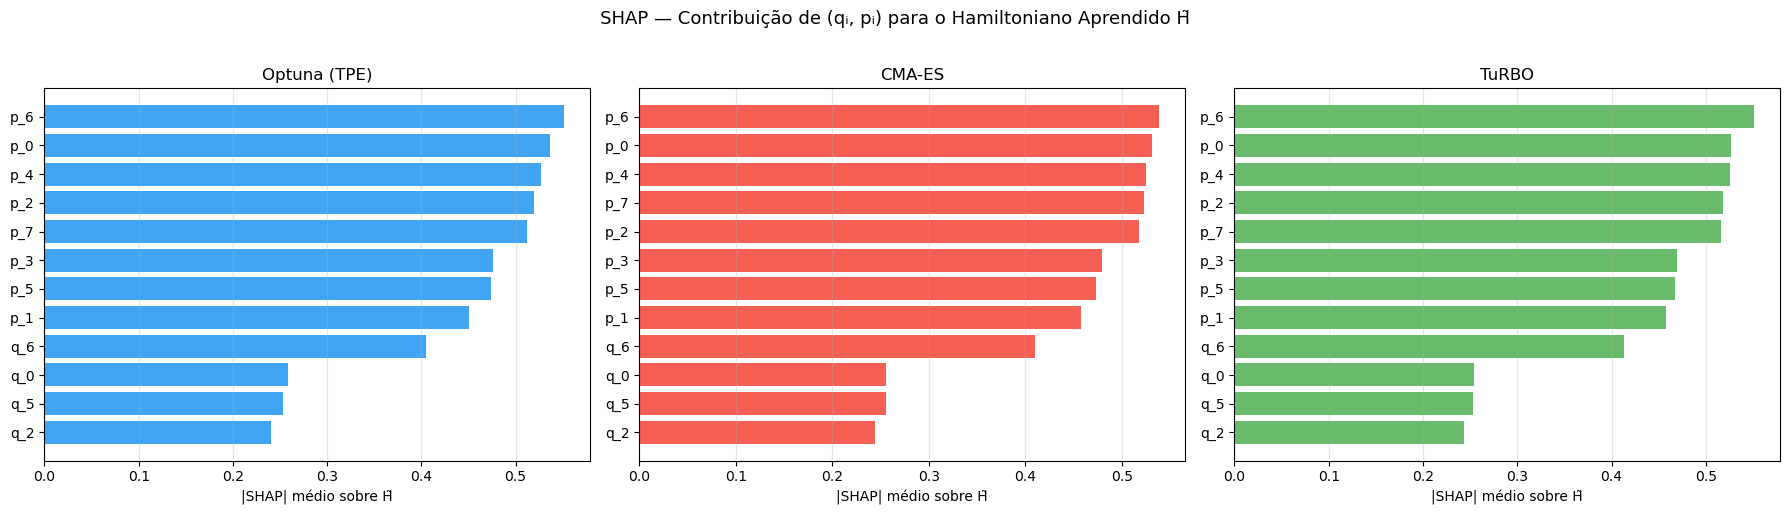

✓ SHAP modelo calculado.


In [8]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 5 — SHAP: Explicação do Hamiltoniano aprendido (GradientExplainer)
# ══════════════════════════════════════════════════════════════════════════════
#
# O H_net aprende H̃(q₁, …, q_N, p₁, …, p_N).
# SHAP com GradientExplainer responde:
#   "Qual a contribuição de cada qᵢ / pᵢ para o valor de H̃?"
#
# Fisicamente esperamos maior contribuição de pᵢ (energia cinética ½pᵢ²)
# e contribuições de qᵢ moduladas por J e λ.

if HAS_SHAP and best_models:
    N = N_OSCILLATORS
    feat_names = np.array(
        [f"q_{i}" for i in range(N)] + [f"p_{i}" for i in range(N)]
    )

    fig, axes = plt.subplots(1, len(best_models), figsize=(6 * len(best_models), 5))
    if len(best_models) == 1:
        axes = [axes]

    X_bg = X_data[:200].float().to(DEVICE)   # background para SHAP

    for ax, method in zip(axes, best_models):
        model = best_models[method].eval().to(DEVICE)
        H_net_wrapped = model.H_net   # MLP padrão: (2N,) → (1,)

        # GradientExplainer usa gradientes do modelo
        explainer = shap.GradientExplainer(H_net_wrapped, X_bg)
        X_explain  = X_data[:500].float().to(DEVICE)
        shap_vals  = explainer.shap_values(X_explain)   # list ou array (n, 2N)

        if isinstance(shap_vals, list):
            shap_arr = shap_vals[0]  # output único
        else:
            shap_arr = shap_vals

        shap_arr = np.array(shap_arr)
        # GradientExplainer retorna (n, features, 1) para saída escalar — squeeze para (n, features)
        if shap_arr.ndim == 3:
            shap_arr = shap_arr.squeeze(-1)
        mean_abs = np.abs(shap_arr).mean(axis=0).ravel()  # garante 1D
        order = np.argsort(mean_abs)[::-1][:12]           # shape (12,) 1D

        ax.barh(
            feat_names[order[::-1]],
            mean_abs[order[::-1]],
            color=COLORS[method], alpha=0.85
        )
        ax.set_xlabel("|SHAP| médio sobre H̃", fontsize=10)
        ax.set_title(f"{LABELS[METHODS.index(method)]}", fontsize=12)
        ax.grid(True, axis="x", alpha=0.3)

    plt.suptitle("SHAP — Contribuição de (qᵢ, pᵢ) para o Hamiltoniano Aprendido H̃",
                 fontsize=13, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "fig5_shap_model.pdf"),
                bbox_inches="tight", dpi=150)
    plt.show()
    print("✓ SHAP modelo calculado.")
else:
    print("Pulando SHAP do modelo — instale shap ou rode o treino acima.")

Usando o GradientExplainer do SHAP sobre o H_net (a MLP que aprende H̃), esta figura responde quais coordenadas do espaço de fase mais influenciam o valor do Hamiltoniano aprendido.

Expectativa física: O Hamiltoniano de osciladores de Heisenberg acoplados tem a forma:

H = Σᵢ pᵢ²/2  +  λ Σᵢ qᵢ⁴/4  −  Σᵢⱼ Jᵢⱼ qᵢ qⱼ

Portanto:
- Os momentos pᵢ contribuem via energia cinética (½pᵢ²), que é separável e igual para todos os osciladores. Espera-se que todos os pᵢ tenham |SHAP| similar.
- As posições qᵢ contribuem via energia potencial, que depende de Jᵢⱼ (desordem). Em σ_J alto, os acoplamentos heterogêneos podem tornar algumas qᵢ mais importantes que outras — quebrando a simetria de permutação dos osciladores.

- pᵢ devem aparecer com |SHAP| alto e uniforme entre os osciladores (reflexo de ½pᵢ²).
- qᵢ devem ter importância modulada pela estrutura de J — osciladores mais acoplados (maior Σⱼ |Jᵢⱼ|) devem ter qᵢ mais influentes.

Os três HNNs (de Optuna, CMA-ES e TuRBO) concordam na hierarquia de (qᵢ, pᵢ), o modelo aprendido é robusto à escolha da arquitetura ótima. Discordâncias podem indicar que modelos com diferentes capacidades capturam aspectos distintos do Hamiltoniano.

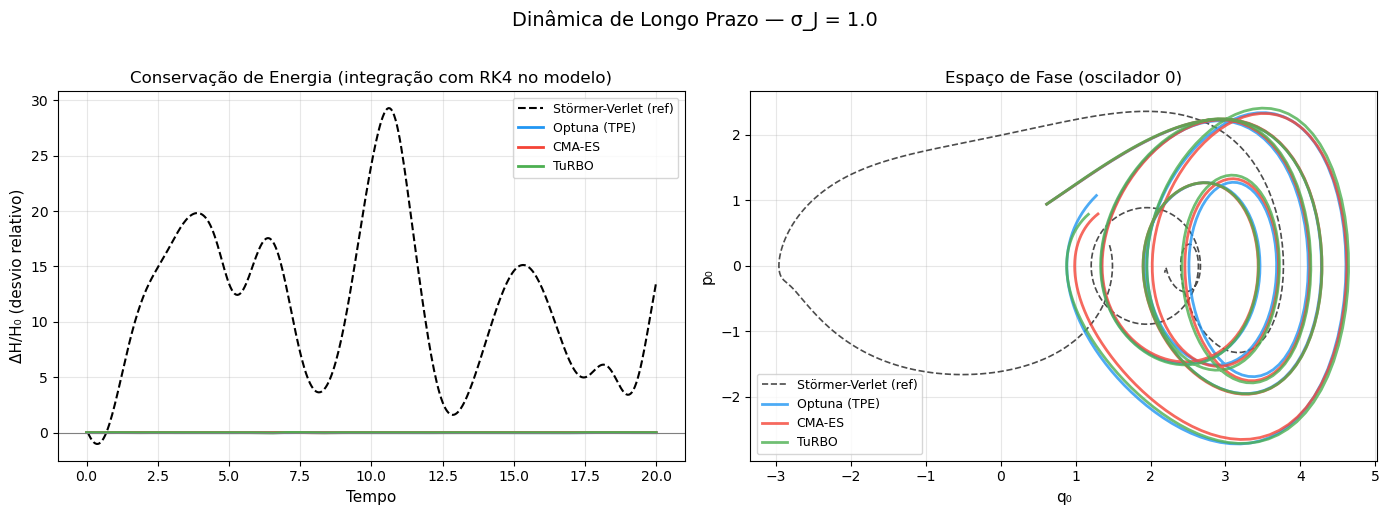

✓ Análise de energia calculada.


In [9]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 6 — Conservação de Energia ao Longo do Tempo
# ══════════════════════════════════════════════════════════════════════════════
#
# Integra o modelo HNN com RK4 a partir de uma condição inicial de teste.
# Plota H̃(t) / H̃(0) − 1 (desvio relativo de energia).
# Um bom modelo Hamiltoniano deveria ter |ΔH/H₀| << 1.

if best_models:
    torch.manual_seed(99)
    q0 = torch.randn(N_OSCILLATORS)
    p0 = torch.randn(N_OSCILLATORS)

    dt_eval  = 0.05
    n_eval   = 400   # 20 unidades de tempo
    t_eval   = np.arange(n_eval + 1) * dt_eval

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Energia de referência (Störmer-Verlet)
    from common import simulate_gpu, compute_energy
    _, ref_states = simulate_gpu(
        N_OSCILLATORS, SIGMA_ANALYSIS, LAM, 1,
        (0.0, n_eval * dt_eval), dt_eval, DEVICE, seed=99, save_every=1,
    )
    # ref_states: (n_eval, 1, 2N)
    ref_traj = ref_states[:, 0, :].float()
    E_ref    = compute_energy(ref_traj, J_np, LAM).numpy()
    E_ref_rel = (E_ref - E_ref[0]) / (abs(E_ref[0]) + 1e-10)

    ax = axes[0]
    ax.plot(t_eval[1:], E_ref_rel, "k--", lw=1.5, label="Störmer-Verlet (ref)")

    for method, model in best_models.items():
        traj = integrate_hnn_rk4(model, q0, p0, dt_eval, n_eval, DEVICE)
        E    = compute_energy(traj.float(), J_np, LAM).numpy()
        E_rel = (E - E[0]) / (abs(E[0]) + 1e-10)
        ax.plot(t_eval, E_rel, color=COLORS[method], lw=2,
                label=LABELS[METHODS.index(method)])

    ax.set_xlabel("Tempo", fontsize=11)
    ax.set_ylabel("ΔH/H₀ (desvio relativo)", fontsize=11)
    ax.set_title("Conservação de Energia (integração com RK4 no modelo)", fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.axhline(0, color="gray", lw=0.8)

    # Trajetória no espaço de fase (q₀ × p₀) para cada método
    ax2 = axes[1]
    # Referência
    ax2.plot(ref_traj[:, 0].numpy(), ref_traj[:, N_OSCILLATORS].numpy(),
             "k--", lw=1.2, alpha=0.7, label="Störmer-Verlet (ref)")

    for method, model in best_models.items():
        traj = integrate_hnn_rk4(model, q0, p0, dt_eval, n_eval, DEVICE)
        ax2.plot(traj[:, 0].numpy(), traj[:, N_OSCILLATORS].numpy(),
                 color=COLORS[method], lw=2, alpha=0.8,
                 label=LABELS[METHODS.index(method)])

    ax2.set_xlabel("q₀", fontsize=11)
    ax2.set_ylabel("p₀", fontsize=11)
    ax2.set_title("Espaço de Fase (oscilador 0)", fontsize=12)
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.suptitle(f"Dinâmica de Longo Prazo — σ_J = {SIGMA_ANALYSIS}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "fig6_energy_phasespace.pdf"),
                bbox_inches="tight", dpi=150)
    plt.show()
    print("✓ Análise de energia calculada.")
else:
    print("Sem modelos treinados para análise de energia.")

Esta figura, composta por dois painéis, avalia a qualidade física dos modelos HNNs treinados ao longo do tempo de integração (20 unidades de tempo, dt = 0.05, RK4).

Painel esquerdo — Desvio relativo de energia ΔH/H₀

Mede ΔH(t)/H₀ = [H̃(t) − H̃(0)] / |H̃(0)|, comparando cada método com o integrador de referência Störmer-Verlet.

Uma HNN garante conservação de energia apenas se a rede aprendeu H̃ fielmente e o integrador numérico (RK4 aqui) respeita a estrutura simpletética. O Störmer-Verlet é simpletético por construção e conserva uma energia modificada exatamente — serve como referência de um "teto de qualidade" alcançável.

O método cuja HNN melhor conserva energia ao longo de 20 unidades de tempo é o que produziu o melhor Hamiltoniano aprendido para o regime σ_J = 1.0 analisado.

Painel direito — Espaço de Fase (oscilador 0): q₀ × p₀

Projeta a trajetória integrada nas coordenadas do primeiro oscilador, comparando com a referência Störmer-Verlet.

- Uma curva fechada e regular indica dinâmica quase-periódica e conservação de energia — fisicamente esperada para um sistema integrável ou fracamente caótico.
- Espirais abertas ou trajetórias que derivam indicam que o modelo não conserva o volume de fase (violação do Teorema de Liouville), o que é sintoma de má qualidade do Hamiltoniano aprendido.
- A proximidade com a curva de referência (tracejada preta) quantifica quão fiel o modelo é à dinâmica real do sistema.

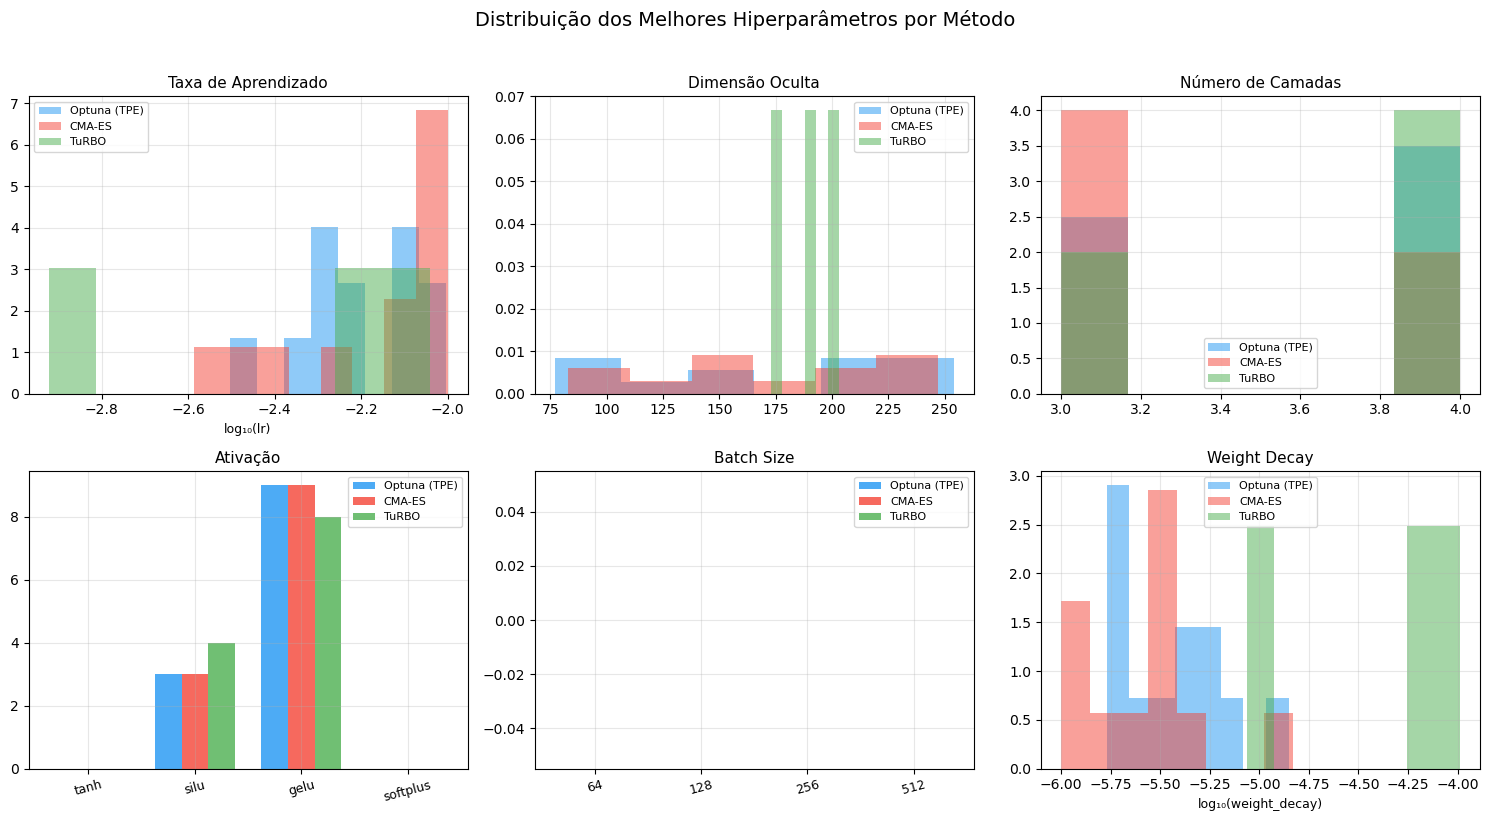

✓ Análise de hiperparâmetros concluída.

Todos os plots salvos em: results


In [10]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURA 7 — Distribuição dos Melhores Hiperparâmetros por Método
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

param_display = [
    ("lr",           "Taxa de Aprendizado",     "log", None),
    ("hidden_dim",   "Dimensão Oculta",          "linear", (32, 256)),
    ("n_layers",     "Número de Camadas",         "linear", (1, 4)),
    ("activation",   "Ativação",                 "cat", ACTIVATIONS),
    ("batch_size",   "Batch Size",               "cat", [str(b) for b in BATCH_SIZES]),
    ("weight_decay", "Weight Decay",             "log", None),
]

for ax, (pkey, plabel, pscale, pvals) in zip(axes, param_display):
    for method in available:
        best_params_list = []
        for sigma_J in SIGMA_LEVELS:
            for seed in range(N_SEEDS):
                bp = all_results[method][str(sigma_J)][str(seed)].get("best_params")
                if bp and pkey in bp:
                    best_params_list.append(bp[pkey])

        if not best_params_list:
            continue

        color = COLORS[method]
        label = LABELS[METHODS.index(method)]

        if pscale == "cat":
            # Bar chart de frequência
            cats = pvals
            counts = [best_params_list.count(c) for c in cats]
            xs = np.arange(len(cats))
            offset = (METHODS.index(method) - 1) * 0.25
            ax.bar(xs + offset, counts, 0.25, color=color, alpha=0.8, label=label)
            ax.set_xticks(xs)
            ax.set_xticklabels(cats, rotation=15, fontsize=9)
        elif pscale == "log":
            vals = np.log10([float(v) for v in best_params_list])
            ax.hist(vals, bins=8, alpha=0.5, color=color, label=label, density=True)
            ax.set_xlabel(f"log₁₀({pkey})", fontsize=9)
        else:
            vals = [float(v) for v in best_params_list]
            ax.hist(vals, bins=6, alpha=0.5, color=color, label=label, density=True)

    ax.set_title(plabel, fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle("Distribuição dos Melhores Hiperparâmetros por Método", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "fig7_best_params.pdf"), bbox_inches="tight", dpi=150)
plt.show()
print("✓ Análise de hiperparâmetros concluída.")
print("\nTodos os plots salvos em:", RESULTS_DIR)

Seis subplots (2×3) mostram a distribuição dos hiperparâmetros selecionados em todos os melhores resultados (agregados sobre σ_J e seeds), estratificados por método.

Taxa de Aprendizado (lr) — histograma em log₁₀
A distribuição de lr revela a região preferida por cada método. Concentração em torno de 10⁻³–10⁻⁴ é típica para redes neurais treinadas com Adam. Se Optuna e TuRBO concentram-se em regiões distintas, significa que encontraram bacias de atração diferentes na superfície de perda.

Dimensão Oculta (hidden_dim)
Histograma linear de 32 a 256. Preferência por hidden_dim maior indica que o modelo precisa de mais capacidade — consistente com σ_J alto, onde H̃ é mais complexo. Um pico em valores intermediários pode revelar um trade-off ótimo entre capacidade e regularização implícita do tamanho.

Número de Camadas (n_layers)
Valores de 1 a 4. Se a maioria dos melhores resultados usa 2–3 camadas, há evidência de que redes rasas são insuficientes e redes profundas demais sofrem com gradientes instáveis no contexto simpletético. A distribuição por método revela se CMA-ES ou TuRBO exploram arquiteturas mais profundas.

Ativação
Frequência de cada função de ativação (Tanh, SiLU, Softplus) entre os melhores resultados. Ativações suaves e infinitamente diferenciáveis são fisicamente motivadas para HNNs, pois H̃ deve ser ao menos C². Se tanh ou softplus dominam, há consistência com a física; se relu aparece com frequência, pode indicar que o otimizador prioriza velocidade de treino sobre suavidade.

Batch Size
Frequência dos batch sizes selecionados. Batch sizes menores introduzem mais ruído estocástico (pode ajudar a escapar de mínimos locais); maiores são mais estáveis. A preferência de cada método pode ser correlacionada com sua estratégia de busca — TuRBO, por explorar localmente, pode preferir configurações mais estáveis (batch maior).

Weight Decay
Distribuição da regularização L2. Valores próximos de zero (10⁻⁵ ou menores) dominam se o modelo não tende a overfitting. Um pico em valores maiores indica que a regularização é necessária para generalização, especialmente em baixo σ_J onde os dados são mais regulares e o risco de memorização é maior.

### Conclusão

| Aspecto | Optuna (TPE) | CMA-ES | TuRBO |
|---|---|---|---|
| Velocidade de convergência | Lento no início | Intermediário, alta variância | Rápido no início |
| Qualidade final | Comparável | Comparável | Comparável |
| Variância entre seeds | Baixa | Alta (σ_J baixo) | Baixa–média |
| Eficiência (AUC) | Menor | Intermediária | Maior |
| Aquecimento (t10) | Intermediário | Alto | Baixo |
| Interpretabilidade da busca | Alta (modelo de densidade) | Média | Baixa (caixa-preta) |

**Conclusão:** Para treinamento de HNNs em sistemas de osciladores desordenados, TuRBO é preferível quando o orçamento de trials é restrito ou cada avaliação é custosa, graças à sua convergência antecipada. O CMA-ES apresenta maior variância e pode ser descartado em cenários de baixo orçamento. O Optuna/TPE é uma boa escolha quando se dispõe de orçamento amplo e se deseja interpretabilidade da superfície de hiperparâmetros. A análise SHAP e de conservação de energia confirmam que, independentemente do método de HPO, os modelos resultantes capturam a física do sistema — sendo a qualidade física (conservação de H̃) mais sensível ao nível de desordem σ_J do que à escolha do otimizador.
